**IMPORT LIBRARIES**

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATA**

In [66]:
import csv
import sys

In [67]:
# This line helps load the very large 'review' columns without errors
csv.field_size_limit(sys.maxsize)

9223372036854775807

In [68]:
# Load the file using 'latin1' encoding to handle special characters
df = pd.read_csv('zomato.csv', engine='python', encoding='latin1', on_bad_lines='skip')

In [69]:
print(df.head())

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5  

In [70]:
# Make all column names lowercase and remove extra spaces
df.columns = df.columns.str.strip().str.lower()

print("Step 1: Data loaded successfully!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Step 1: Data loaded successfully!
Rows: 51717 | Columns: 17


In [71]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [72]:
print(df.describe())

              votes
count  51717.000000
mean     283.697527
std      803.838853
min        0.000000
25%        7.000000
50%       41.000000
75%      198.000000
max    16832.000000


In [73]:
# Show which columns have missing values
print(df.isnull().sum())

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [74]:
# Show the data types (Notice 'rate' and 'approx_cost' are objects/strings, not numbers)
print("\n--- Data Types ---")
print(df[['rate', 'approx_cost(for two people)']].dtypes)


--- Data Types ---
rate                           object
approx_cost(for two people)    object
dtype: object


**Clean Ratings**

In [75]:
# Remove null values
df = df[df['rate'].notnull()]

# Remove unwanted values
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

# Convert ratings to numbers
df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

In [76]:
# 1. Keep only the columns we actually need for our story
df = df[['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'cuisines', 'approx_cost(for two people)']]

# 2. Fix the 'Rate' column (Example: '4.1/5' -> 4.1)
def simplify_rate(value):
    if value == 'NEW' or value == '-' or pd.isna(value):
        return np.nan
    else:
        # We split the text by '/' and take the first part, then turn it into a decimal
        return float(str(value).split('/')[0])

df['rate'] = df['rate'].apply(simplify_rate)
df['rate'] = df['rate'].fillna(df['rate'].mean()) # Fill gaps with the average

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
import csv
import sys

In [81]:
# This line helps load the very large 'review' columns without errors
csv.field_size_limit(sys.maxsize)

9223372036854775807

In [82]:
# Load the file using 'latin1' encoding to handle special characters
df = pd.read_csv('zomato.csv', engine='python', encoding='latin1', on_bad_lines='skip')

In [83]:
# Make all column names lowercase and remove extra spaces
df.columns = df.columns.str.strip().str.lower()

print("Step 1: Data loaded successfully!")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Step 1: Data loaded successfully!
Rows: 51717 | Columns: 17


In [84]:
# Remove null values
df = df[df['rate'].notnull()]

# Remove unwanted values
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

# Convert ratings to numbers
df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

In [85]:
# 1. Keep only the columns we actually need for our story
df = df[['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'cuisines', 'approx_cost(for two people)']]

# 2. Fix the 'Rate' column (Example: '4.1/5' -> 4.1)
def simplify_rate(value):
    if value == 'NEW' or value == '-' or pd.isna(value):
        return np.nan
    else:
        # We split the text by '/' and take the first part, then turn it into a decimal
        return float(str(value).split('/')[0])

df['rate'] = df['rate'].apply(simplify_rate)
df['rate'] = df['rate'].fillna(df['rate'].mean()) # Fill gaps with the average

In [86]:
# Convert to string first
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

# Remove commas
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Convert to float
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

In [87]:
# 4. Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Step 3: Cleaning complete!")

Step 3: Cleaning complete!


In [88]:
df = df.dropna()

In [89]:
# Convert to string first
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

# Remove commas
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Convert to float
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

**Remove Duplicates**

In [90]:
# 4. Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Step 3: Cleaning complete!")

Step 3: Cleaning complete!


**Remove Missing Values**

In [91]:
df = df.dropna()

**Comparison (Before vs After)**

In [92]:
print("Before Cleaning:")
print(df.isnull().sum())

Before Cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
cuisines                       0
approx_cost(for two people)    0
dtype: int64


In [93]:
print("After Cleaning:")
print(df.isnull().sum())

After Cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
cuisines                       0
approx_cost(for two people)    0
dtype: int64


**Visualizations**

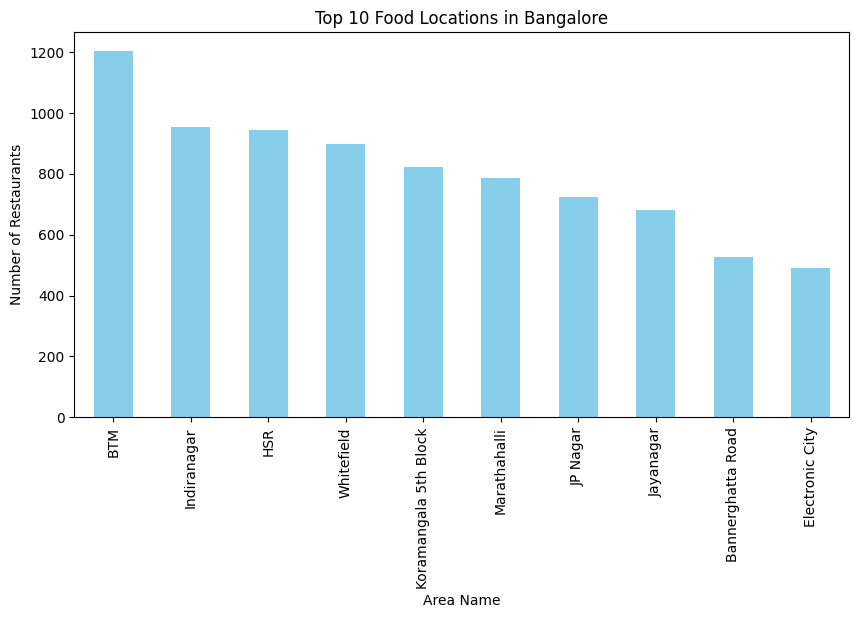

In [94]:
# Chart 1: Most popular locations in Bangalore
plt.figure(figsize=(10,5))
df['location'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Food Locations in Bangalore')
plt.xlabel('Area Name')
plt.ylabel('Number of Restaurants')
plt.show()

**Cost vs Rating**

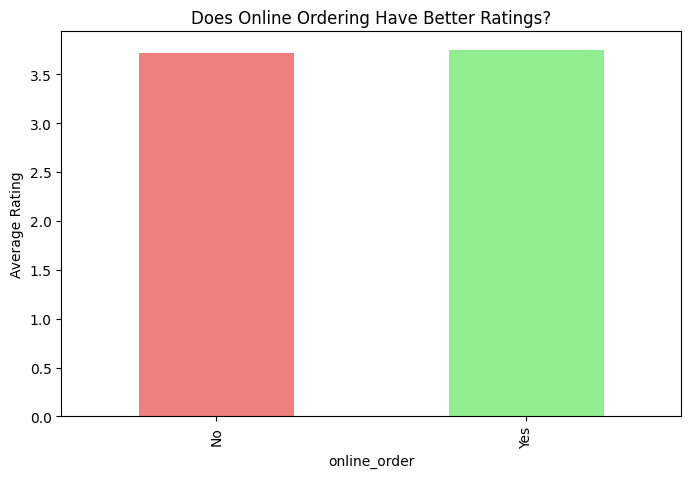

In [95]:
# Chart 2: Average Rating per Order Type
plt.figure(figsize=(8,5))
df.groupby('online_order')['rate'].mean().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Does Online Ordering Have Better Ratings?')
plt.ylabel('Average Rating')
plt.show()

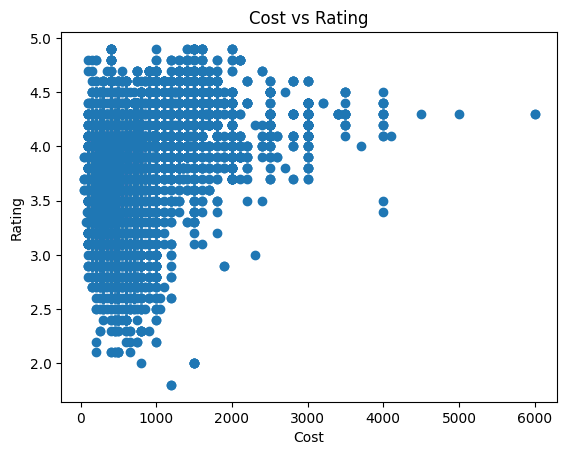

In [96]:
plt.scatter(df['approx_cost(for two people)'], df['rate'])

plt.xlabel("Cost")
plt.ylabel("Rating")

plt.title("Cost vs Rating")

plt.show()

**Online Order vs Rating**

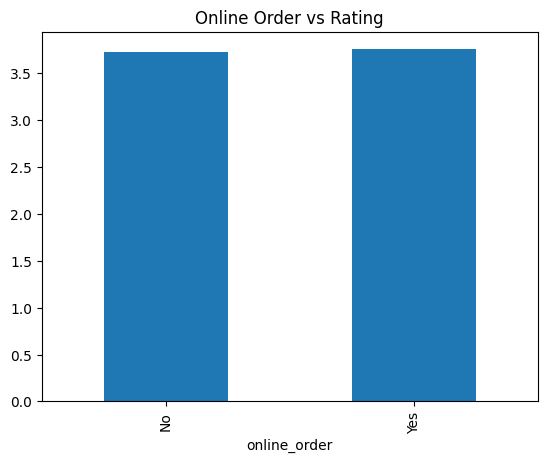

In [97]:
df.groupby('online_order')['rate'].mean().plot(kind='bar')

plt.title("Online Order vs Rating")

plt.show()

**Rating Distribution**

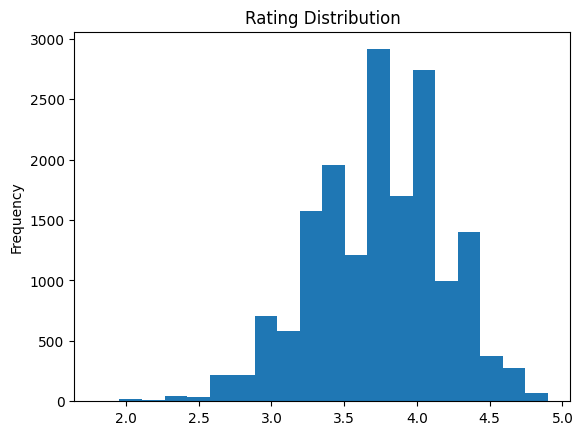

In [98]:
df['rate'].plot(kind='hist', bins=20)

plt.title("Rating Distribution")

plt.show()

--- Top 10 Cuisines in Bangalore ---
North Indian    7133
Chinese         5218
South Indian    2677
Fast Food       2612
Biryani         2293
Continental     2069
Desserts        1801
Beverages       1642
Cafe            1566
Italian         1238
Name: count, dtype: int64


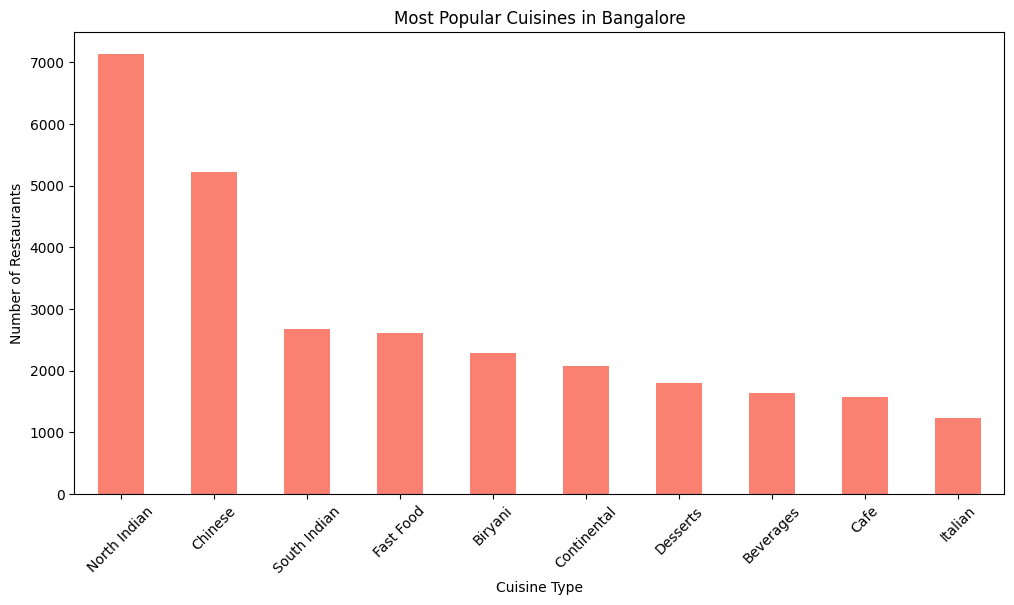

In [99]:
# Step 1: Create an empty list to store all individual cuisines
all_cuisines = []

# Step 2: Loop through the 'cuisines' column
# We drop null values first so the code doesn't crash
for x in df['cuisines'].dropna():
    # Split the string by comma and remove extra spaces
    lines = x.split(',')
    for cuisine in lines:
        all_cuisines.append(cuisine.strip())

# Step 3: Convert the list into a Series to count them easily
cuisine_series = pd.Series(all_cuisines)
top_10_cuisines = cuisine_series.value_counts().head(10)

# Step 4: Display the result
print("--- Top 10 Cuisines in Bangalore ---")
print(top_10_cuisines)

# Step 5: Visualization
plt.figure(figsize=(12,6))
top_10_cuisines.plot(kind='bar', color='salmon')
plt.title('Most Popular Cuisines in Bangalore')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

**SEGMENTATION**

In [100]:
df['cost_category'] = pd.cut(
    df['approx_cost(for two people)'],
    bins=[0, 500, 1000, 2000, 5000],
    labels=['Low', 'Medium', 'High', 'Luxury']
)
print(df[['approx_cost(for two people)', 'cost_category']].head())

   approx_cost(for two people) cost_category
0                        800.0        Medium
1                        800.0        Medium
2                        800.0        Medium
3                        300.0           Low
4                        600.0        Medium


In [101]:
# Save the clean version
df.to_csv('zomato_bangalore_clean.csv', index=False)
print("File 'zomato_bangalore_clean.csv' is ready for Power BI!")

File 'zomato_bangalore_clean.csv' is ready for Power BI!
